In [5]:
import xarray as xr
import pandas as pd
import numpy as np
import os
import re
from datetime import datetime
import pyresample as pr
from pyresample import kd_tree, parse_area_file
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from pyresample.geometry import SwathDefinition
import sys, string, math, cmath
from numba import jit 
from tqdm import tqdm 
import time 
from pyresample.geometry import SwathDefinition
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.ticker import FixedLocator 
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import maximum_filter, minimum_filter

In [6]:
# Open the filtered swath data and store it in a Pandas Dataframe
file_path_swath ='data_swath4.txt'
data_swath = pd.read_csv(file_path_swath, delimiter='\t')

# Convert all numeric columns to numeric data types
numeric_columns = ['TBCH1', 'TBCH2', 'TBCH3', 'LAT', 'LON', 'u10', 
                   'v10', 't2m', 'tcw', 'tcwv', 'sst', 'siconc',
                   'theta', 'clw', 'W', 'siconc_unc_ch1', 
                   'siconc_unc_ch2', 'T22_measured', 'T32_measured',
                   'T22_mean', 'T32_mean', 'TBCH1_corr', 'TBCH2_corr',
                   'siconc_ch1_corr', 'siconc_ch2_corr']

data_swath[numeric_columns] = data_swath[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Convert 'datetime' column to datetime type 
data_swath['datetime'] = pd.to_datetime(data_swath['datetime'])

# Define conditions for filtering based on regions of interest
myi_condition = (data_swath['LAT'] > 80) & (data_swath['LAT'] < 90) & (data_swath['LON'] > -180) & (data_swath['LON'] < 0)
fyi_condition_arctic = (data_swath['LAT'] > 70) & (data_swath['LAT'] < 80) & (data_swath['LON'] > 0) & (data_swath['LON'] < 180)
fyi_condition_antarctic = (data_swath['LAT'] < -70) & (data_swath['LAT'] > -80) & (data_swath['LON'] > -180) & (data_swath['LON'] < 180)

# Define two conditions for each ice-type using logical OR
fyi_condition = (
    (fyi_condition_arctic) |  # First-Year Ice condition in the Arctic
    (fyi_condition_antarctic)  # First-Year Ice condition in the Antarctic
)

myi_condition = (myi_condition)  # Multi-Year Ice condition (Only Arctic)

# Filter the data based on the regions of interest 
data_swath_fyi = data_swath[fyi_condition].dropna() # FYI
data_swath_myi = data_swath[myi_condition].dropna() # MYI

In [7]:
# Divide the data based on the 'LAT' column and open water/ice type
data_nh_ow = data_swath[data_swath['LAT'] > 0]  # Rows where LAT > 0
data_sh_ow = data_swath[data_swath['LAT'] < 0]  # Rows where LAT < 0

data_nh_fyi = data_swath_fyi[data_swath_fyi['LAT'] > 0] 
data_sh_fyi = data_swath_fyi[data_swath_fyi['LAT'] < 0]

data_nh_myi = data_swath_myi[data_swath_myi['LAT'] > 0] 
data_sh_myi = data_swath_myi[data_swath_myi['LAT'] < 0]

# Function to calculate open water, FYI and MYI tie points
def two_channel_tie_points_calculator(tb_data_fyi, tb_data_myi, tb_data_ow, sic_data_fyi, 
                                      sic_data_myi, sic_data_ow, ice_threshold=0.99, open_water_threshold=0.01):
    """
    Derive tie points for first-year ice (FYI), multi-year ice (MYI) and open water (OW) 
    from brightness temperature and SIC data for the two channel algorithm.
    
    Parameters:
    
    tb_data_ow (array): Brightness temperature values (K) for all regions of open water.
    tb_data_fyi (array): Brightness temperature values (K) for regions of first-year ice.
    tb_data_myi (array): Brightness temperature values (K) for regions of multi-year ice.
    
    sic_data_ow (array): ERA5-model SIC values (0 to 1) for all regions of open water.
    sic_data_fyi (array): ERA5-model SIC values (0 to 1) for regions of first-year ice.
    sic_data_myi (array): ERA5-model SIC values (0 to 1) for regions of multi-year ice.
    
    ice_threshold (float): Threshold to classify ice at SIC > 0.99 (Likely to find ice).
    open_water_threshold (float): Threshold to classify open water at SIC < 0.01 (no ice).
    
    Returns:
    tuple: (Tie point for open water, Tie point for ice)
    """
    # Filter data for SIC ≈ 0 (open water) and SIC ≈ 1 (ice)
    open_water_tb = tb_data_ow[sic_data_ow <= open_water_threshold]
    ice_fyi_tb = tb_data_fyi[sic_data_fyi >= ice_threshold]
    ice_myi_tb = tb_data_myi[sic_data_myi >= ice_threshold]
    
    # Calculate mean brightness temperatures as tie points
    tp_open_water = np.mean(open_water_tb) if len(open_water_tb) > 0 else np.nan
    tp_fyi_ice = np.mean(ice_fyi_tb) if len(ice_fyi_tb) > 0 else np.nan
    tp_myi_ice = np.mean(ice_myi_tb) if len(ice_myi_tb) > 0 else np.nan
    
    return tp_open_water, tp_fyi_ice, tp_myi_ice

In [8]:
# TBCH1 for all types of regions
tb1_data_fyi_nh = data_nh_fyi['TBCH1']
tb1_data_myi_nh = data_nh_myi['TBCH1']
tb1_data_ow_nh = data_nh_ow['TBCH1']

# TBCH2 for all types of regions
tb2_data_fyi_nh = data_nh_fyi['TBCH2']
tb2_data_myi_nh = data_nh_myi['TBCH2']
tb2_data_ow_nh = data_nh_ow['TBCH2']

# ERA-5 SIC for all types of regions
sic_data_fyi_nh =  data_nh_fyi['siconc']
sic_data_myi_nh = data_nh_myi['siconc']
sic_data_ow_nh = data_nh_ow['siconc']

# Derive tie points for Channel 1 (22 GHz)
tp_open_water_22ghz_nh, tp_fyi_ice_22ghz_nh, tp_myi_ice_22ghz_nh = two_channel_tie_points_calculator(tb1_data_fyi_nh, tb1_data_myi_nh, tb1_data_ow_nh, 
                                                                                                     sic_data_fyi_nh, sic_data_myi_nh, sic_data_ow_nh, 
                                                                                                     ice_threshold=0.99, open_water_threshold=0.01)

# Derive tie points for Channel 2 (32 GHz)
tp_open_water_32ghz_nh, tp_fyi_ice_32ghz_nh, tp_myi_ice_32ghz_nh = two_channel_tie_points_calculator(tb2_data_fyi_nh, tb2_data_myi_nh, tb2_data_ow_nh, 
                                                                                                     sic_data_fyi_nh, sic_data_myi_nh, sic_data_ow_nh, 
                                                                                                     ice_threshold=0.99, open_water_threshold=0.01)

print(f"22 GHz Tie Points for Northern hemisphere - Open Water: {tp_open_water_22ghz_nh:.2f} K, FYI: {tp_fyi_ice_22ghz_nh:.2f} K, MYI: {tp_myi_ice_22ghz_nh:.2f} K")
print(f"32 GHz Tie Points for Northern hemisphere - Open Water: {tp_open_water_32ghz_nh:.2f} K, FYI: {tp_fyi_ice_32ghz_nh:.2f} K, MYI: {tp_myi_ice_32ghz_nh:.2f} K")


22 GHz Tie Points for Northern hemisphere - Open Water: 170.62 K, FYI: 237.80 K, MYI: 212.65 K
32 GHz Tie Points for Northern hemisphere - Open Water: 169.51 K, FYI: 228.84 K, MYI: 197.86 K


In [9]:
# TBCH1 for all types of regions
tb1_data_fyi_sh = data_sh_fyi['TBCH1']
tb1_data_myi_sh = data_nh_myi['TBCH1'] # We use the north hemisphere MYI signature for Antarctica as well
tb1_data_ow_sh = data_sh_ow['TBCH1']

# TBCH2 for all types of regions
tb2_data_fyi_sh = data_sh_fyi['TBCH2']
tb2_data_myi_sh = data_nh_myi['TBCH2'] # We use the north hemisphere MYI signature for Antarctica as well
tb2_data_ow_sh = data_sh_ow['TBCH2']

# ERA-5 SIC for all types of regions
sic_data_fyi_sh =  data_sh_fyi['siconc']
sic_data_myi_sh = data_nh_myi['siconc'] # We use the north hemisphere MYI signature for Antarctica as well
sic_data_ow_sh = data_sh_ow['siconc']

# Derive tie points for Channel 1 (22 GHz)
tp_open_water_22ghz_sh, tp_fyi_ice_22ghz_sh, tp_myi_ice_22ghz_sh = two_channel_tie_points_calculator(tb1_data_fyi_sh, tb1_data_myi_sh, tb1_data_ow_sh, 
                                                                                                     sic_data_fyi_sh, sic_data_myi_sh, sic_data_ow_sh, 
                                                                                                     ice_threshold=0.99, open_water_threshold=0.01)

# Derive tie points for Channel 2 (32 GHz)
tp_open_water_32ghz_sh, tp_fyi_ice_32ghz_sh, tp_myi_ice_32ghz_sh = two_channel_tie_points_calculator(tb2_data_fyi_sh, tb2_data_myi_sh, tb2_data_ow_sh, 
                                                                                                     sic_data_fyi_sh, sic_data_myi_sh, sic_data_ow_sh, 
                                                                                                     ice_threshold=0.99, open_water_threshold=0.01)

print(f"22 GHz Tie Points for Southern hemisphere - Open Water: {tp_open_water_22ghz_sh:.2f} K, FYI: {tp_fyi_ice_22ghz_sh:.2f} K, MYI: {tp_myi_ice_22ghz_sh:.2f} K")
print(f"32 GHz Tie Points for Southern hemisphere - Open Water: {tp_open_water_32ghz_sh:.2f} K, FYI: {tp_fyi_ice_32ghz_sh:.2f} K, MYI: {tp_myi_ice_32ghz_sh:.2f} K")


22 GHz Tie Points for Southern hemisphere - Open Water: 159.81 K, FYI: 233.81 K, MYI: 212.65 K
32 GHz Tie Points for Southern hemisphere - Open Water: 159.18 K, FYI: 227.92 K, MYI: 197.86 K


In [10]:
# Define the fcomiso 2 channels ice concentration algorithm

def fcomiso(tb_22_GHz, tb_32_GHz, tie_points=None):
    """Comiso ice concentration algorithm."""
   
    tp_ow_22v, tp_ow_32v, tp_myi_22v, tp_myi_32v, tp_fyi_22v, tp_fyi_32v = tie_points

    af = (tp_fyi_32v - tp_myi_32v) / (tp_fyi_22v - tp_myi_22v)
    bf = tp_myi_32v - af * tp_myi_22v
    qf = (tb_32_GHz - tp_ow_32v) / (tb_22_GHz - tp_ow_22v)
    wf = tp_ow_32v - qf * tp_ow_22v
    ti22vf = (bf - wf) / (qf - af)
    sic_2_channels = (tb_22_GHz - tp_ow_22v) / (ti22vf - tp_ow_22v)

    return sic_2_channels 

In [62]:
# Define the function to compute the tie-points-based means for the atmospheric variables for each hemisphere
def calculate_tie_point_means_for_hemispheres(data_nh, data_sh, ice_threshold=0.99, open_water_threshold=0.01):

    """
    Calculate tie-point-based means for open water and ice for specific variables
    for both hemispheres and return all means as a dictionary.
    
    Parameters:
    data_nh (pd.DataFrame): DataFrame for the Northern Hemisphere.
    data_sh (pd.DataFrame): DataFrame for the Southern Hemisphere.
    ice_threshold (float): SIC threshold to classify ice (default: > 0.99).
    open_water_threshold (float): SIC threshold to classify open water (default: < 0.01).
    
    Returns:
    dict: A dictionary with variable names for both hemispheres and their open water and ice means.
    """
    def calculate_means(data, hemisphere):
        # Separate the data into open water and ice based on 'siconc_r'
        open_water_mask = data['siconc'] < open_water_threshold
        ice_mask = data['siconc'] > ice_threshold

        # Calculate means for each variable explicitly with unique names
        return {
            f't2m_mean_open_water_{hemisphere}': data.loc[open_water_mask, 't2m'].mean(),
            f't2m_mean_ice_{hemisphere}': data.loc[ice_mask, 't2m'].mean(),
            
            f'sst_mean_open_water_{hemisphere}': data.loc[open_water_mask, 'sst'].mean(),
            f'sst_mean_ice_{hemisphere}': data.loc[ice_mask, 'sst'].mean(),
            
            f'tcwv_mean_open_water_{hemisphere}': data.loc[open_water_mask, 'tcwv'].mean(),
            f'tcwv_mean_ice_{hemisphere}': data.loc[ice_mask, 'tcwv'].mean(),
            
            f'clw_mean_open_water_{hemisphere}': data.loc[open_water_mask, 'clw'].mean(),
            f'clw_mean_ice_{hemisphere}': data.loc[ice_mask, 'clw'].mean(),
            
            f'W_mean_open_water_{hemisphere}': data.loc[open_water_mask, 'W'].mean(),
            f'W_mean_ice_{hemisphere}': data.loc[ice_mask, 'W'].mean(),
        }

    # Calculate means for both hemispheres
    means_nh = calculate_means(data_nh, 'NH')
    means_sh = calculate_means(data_sh, 'SH')

    # Combine results into a single dictionary
    return {**means_nh, **means_sh}

# Function to implement the two channels algorithm for SIC computation at both hemispheres on swath-type dataframe
def calculate_SIC_two_channels(swath_data, TB1_col, TB2_col, output_col_sic='siconc_unc_2_channels'):
    """
    Calculate the sea ice concentration using the two-channel fcomiso algorithm.

    Parameters:
        swath_data (pd.DataFrame): The input DataFrame containing the swath measurements.
        TB1_measured_col (str): Column name for measured brightness temperature at 22 GHz.
        TB2_measured_col (str): Column name for measured brightness temperature at 32 GHz.
        output_col_sic (str): Name of the output column for the calculated sea ice concentration using two channels.

    Returns:
        pd.DataFrame: DataFrame with an additional column for sea ice concentration using the two-channel algorithm.
    """
    # Define function to get tie points based on latitude
    def get_tie_points(lat):
        if lat > 0:  # Northern Hemisphere
            return [
                tp_open_water_22ghz_nh, tp_open_water_32ghz_nh,
                tp_myi_ice_22ghz_nh, tp_myi_ice_32ghz_nh,
                tp_fyi_ice_22ghz_nh, tp_fyi_ice_32ghz_nh
            ]
        else:  # Southern Hemisphere
            return [
                tp_open_water_22ghz_sh, tp_open_water_32ghz_sh,
                tp_myi_ice_22ghz_sh, tp_myi_ice_32ghz_sh,
                tp_fyi_ice_22ghz_sh, tp_fyi_ice_32ghz_sh
            ]

    # Apply tie points and calculate SIC using fcomiso
    def compute_sic(row):
        # Get tie points for the latitude
        tie_points = get_tie_points(row['LAT'])
        
        # Use the fcomiso function with the row's brightness temperatures
        return fcomiso(row[TB1_col], row[TB2_col], tie_points=tie_points)

    # Apply the SIC calculation to each row in the DataFrame
    swath_data[output_col_sic] = swath_data.apply(compute_sic, axis=1)

    # Clamp values to the range [0, 1]
    swath_data[output_col_sic] = swath_data[output_col_sic].clip(lower=0, upper=1)

        
    # Apply open-water filter (force values below 0.15 to 0)
    swath_data.loc[swath_data[output_col_sic] < 0.15, output_col_sic] = 0
   
    return swath_data


# Call the function and calculate the sea ice concentration using the two-channel algorithm
data_swath = calculate_SIC_two_channels(
    data_swath, # Selected swath-type dataframe
    TB1_col='TBCH1',  # 22 GHz brightness temperature
    TB2_col='TBCH2',  # 32 GHz brightness temperature
    output_col_sic='siconc_unc_2_channels' # newcolumn in data_swath dataframe
)

In [54]:
# Divide the data based on the 'LAT' column
data_nh = data_swath[data_swath['LAT'] > 0]  # Rows where LAT > 0
data_sh = data_swath[data_swath['LAT'] < 0]  # Rows where LAT < 0


# Calculate tie-points-based means for the atmospheric variables in both hemispheres
tie_point_means = calculate_tie_point_means_for_hemispheres(data_nh, data_sh)

In [13]:
# Define Optimized RTM Function

@jit(nopython=True)  # This compiles the function into machine code
def scams_optimized(V, W, L, Ta, Ts, theta, Ti_amsrv, Ti_amsrh, c_ice_ch1, c_ice_ch2, e_icev, e_iceh):
    
    """---------------------------------------------------------------------------
     AMSR Ocean Algorithm; Frank J. Wentz, Thomas Meissner; Remote
     Sensing Systems; Version 2; November 2; 2000. Modified to NIMBUS 6 SCAMS geometry.
     NIMBUS 6 SCAMS Scanning Microwave Spectrometer 145 km spatial resolution 2400 km swath
     T22, T32: scams(V,W,L,Ta,Ts,theta,Ti_amsrv,Ti_amsrh,c_ice_ch1, c_ice_ch2,e_icev,e_iceh)
     V: columnar water vapor [mm] # we use the mean value from the tie points 
     W: windspeed over water [m/s] # we use the mean value from the tie points
     L: columnar cloud liquid water [mm] # we use the mean value from the tie points that is L=tcw-tcwv in our ERA5 model variables
     Ti_amrsv: ice emitting layer temperature (usually warmer than atmosphere temperature in Winter) vertical polarization
     Ti_amrsh: ice emitting layer temperature (usually warmer than atmosphere temperature in Winter) horizontal polarization
     Ti: 0.6*Ta + 0.4 # we use this fixed value in the equation
     Ta: atmospheric temperature at 2 m altitude = t2m in our ERA5-data 
     Ts: sea surface temperature [K]
     theta: incidence angle [deg]
     Ti: ice surface temperature [K]
     c_ice: ice concentration [0-1]
     e_ice: ice emissivity [0-1]  We use the same ice emissivity: 0.8 for horizontal polarization and 0.9 for vertical polarization (educated guess)
     -------------------------------------------------------------------------------"""
    frequencies = np.array([23.80, 36.50])

    b0 = np.array([241.69, 239.45])
    b1 = np.array([310.32E-2, 254.41E-2])
    b2 = np.array([-814.29E-4, -512.84E-4])
    b3 = np.array([998.93E-6, 452.02E-6])
    b4 = np.array([-48.37E-7, -14.36E-7])
    b5 = np.array([0.20, 0.58])
    b6 = np.array([-0.20, -0.57])
    b7 = np.array([-5.21E-2, -2.38E-2])
    ao1 = np.array([15.75E-3, 40.06E-3])
    ao2 = np.array([-0.87E-4, -2.00E-4])
    av1 = np.array([5.14E-3, 1.88E-3])
    av2 = np.array([0.19E-5, 0.09E-5])

    aL1 = np.array([0.0891, 0.2027])
    aL2 = np.array([0.0281, 0.0261])

    r0v = np.array([-0.63E-3, -1.01E-3])
    r0h = np.array([1.39E-3, 1.91E-3])
    r1v = np.array([-0.70E-4, -1.05E-4])
    r1h = np.array([0.85E-4, 1.12E-4])
    r2v = np.array([-2.10E-5, -2.10E-5])
    r2h = np.array([-41.95E-6, -54.51E-6])
    r3v = np.array([0.41E-6, 0.45E-6])
    r3h = np.array([-0.20E-6, -0.36E-6])

    m1v = np.array([0.00178, 0.00257])
    m1h = np.array([0.00308, 0.00329])
    m2v = np.array([0.00730, 0.00701])
    m2h = np.array([0.00660, 0.00660])

    # Constants
    T_C = 2.7
    light_speed = 3.00E10
    epsilon_R = 4.44
    s = 35.0
    ny = 0.012

    
    # Precompute mixed temperatures for both channels
    Ts_mix_ch1 = c_ice_ch1 * Ta + (1.0 - c_ice_ch1) * Ts
    Ts_mix_ch2 = c_ice_ch2 * Ta + (1.0 - c_ice_ch2) * Ts

    Tl_ch1 = (Ts_mix_ch1 + 273.0) / 2.0
    Tl_ch2 = (Ts_mix_ch2 + 273.0) / 2.0

    # Eq. 27
    Tv = np.where(V > 48, 301.16, 273.16 + 0.8337 * V - 3.029E-5 * (V**3.33))

    # Precompute G for both channels
    Ts_Tv_diff_ch1 = Ts_mix_ch1 - Tv
    Ts_Tv_diff_ch2 = Ts_mix_ch2 - Tv

    G_ch1 = np.where(
        np.abs(Ts_Tv_diff_ch1) > 20,
        Ts_Tv_diff_ch1 * 14 / np.abs(Ts_Tv_diff_ch1),
        1.05 * Ts_Tv_diff_ch1 * (1 - (Ts_Tv_diff_ch1**2) / 1200.0)
    )
    G_ch2 = np.where(
        np.abs(Ts_Tv_diff_ch2) > 20,
        Ts_Tv_diff_ch2 * 14 / np.abs(Ts_Tv_diff_ch2),
        1.05 * Ts_Tv_diff_ch2 * (1 - (Ts_Tv_diff_ch2**2) / 1200.0)
    )

    # Shared precomputations
    Ts_K = Ts - 273.15
    epsilon_S = 87.90 * np.exp(-0.004585 * Ts_K) * np.exp(-3.45E-3 * s + 4.69E-6 * s**2 + 1.36E-5 * s * Ts_K)
    lambda_R = 3.30 * np.exp(-0.0346 * Ts_K + 0.00017 * Ts_K**2) - (6.54E-3 * (1 - 3.06E-2 * Ts_K + 2.0E-4 * Ts_K**2) * s)
    C = 0.5536 * s
    delta_t = 25.0 - Ts_K
    qsi = (
        2.03E-2
        + 1.27E-4 * delta_t
        + 2.46E-6 * delta_t**2
        - C * (3.34E-5 - 4.60E-7 * delta_t + 4.60E-8 * delta_t**2)
    )
    sigma = 3.39E9 * (C**0.892) * np.exp(-delta_t * qsi)

    # Initialize output arrays
    tau = np.zeros(2)
    TBU = np.zeros(2)
    TBD = np.zeros(2)
    emissivity_h = np.zeros(2)
    emissivity_v = np.zeros(2)
    T_BOmegaH = np.zeros(2)
    T_BOmegaV = np.zeros(2)

    theta_rad = np.radians(theta)
    cos_theta = np.cos(theta_rad)
    sin_theta = np.sin(theta_rad)

    # Vectorized loop computations
    for i in range(2):
        # Eq. 26
        TD = b0[i] + b1[i] * V + b2[i] * V**2 + b3[i] * V**3 + b4[i] * V**4 + b5[i] * (G_ch1 if i == 0 else G_ch2)
        TU = TD + b6[i] + b7[i] * V

        # Eq. 28-29
        AO = ao1[i] + ao2[i] * (TD - 270.0)
        AV = av1[i] * V + av2[i] * V**2

        # Eq. 33
        AL = aL1[i] * (1.0 - aL2[i] * ((Tl_ch1 if i == 0 else Tl_ch2) - 283.0)) * L

        # Eq. 22
        tau[i] = np.exp((-1.0 / cos_theta) * (AO + AV + AL))
        TBU[i] = TU * (1.0 - tau[i])
        TBD[i] = TD * (1.0 - tau[i])

        # Wavelength and epsilon
        llambda = light_speed / (frequencies[i] * 1E9)
        epsilon = (
            epsilon_R
            + ((epsilon_S - epsilon_R) / (1.0 + ((1j * lambda_R) / llambda)**(1.0 - ny)))
            - ((2.0 * 1j * sigma * llambda) / light_speed)
        )

        # Eq. 45
        sqrt_term = np.sqrt(epsilon - np.sin(theta_rad)**2)
        rho_H = (cos_theta - sqrt_term) / (cos_theta + sqrt_term)
        rho_V = (epsilon * cos_theta - sqrt_term) / (epsilon * cos_theta + sqrt_term)

        R_0H = np.abs(rho_H)**2
        R_0V = np.abs(rho_V)**2 + (4.887E-8 - 6.108E-8 * (Ts - 273.0)**3)

        # Eq. 57
        R_geoH = R_0H - (r0h[i] + r1h[i] * (theta - 53.0) + r2h[i] * (Ts - 288.0) + r3h[i] * (theta - 53.0) * (Ts - 288.0)) * W
        R_geoV = R_0V - (r0v[i] + r1v[i] * (theta - 53.0) + r2v[i] * (Ts - 288.0) + r3v[i] * (theta - 53.0) * (Ts - 288.0)) * W

        # Eq. 60
        F_H = np.where(
            W < 7.0, m1h[i] * W,
            np.where(W < 12.0, m1h[i] * W + 0.5 * (m2h[i] - m1h[i]) * ((W - 7.0)**2) / (12.0 - 7.0),
                     m2h[i] * W - 0.5 * (m2h[i] - m1h[i]) * (12.0 + 7.0))
        )

        F_V = np.where(
            W < 3.0, m1v[i] * W,
            np.where(W < 12.0, m1v[i] * W + 0.5 * (m2v[i] - m1v[i]) * ((W - 3.0)**2) / (12.0 - 3.0),
                     m2v[i] * W - 0.5 * (m2v[i] - m1v[i]) * (12.0 + 3.0))
        )

        R_H = (1 - F_H) * R_geoH
        R_V = (1 - F_V) * R_geoV
        emissivity_h[i] = 1 - R_H
        emissivity_v[i] = 1 - R_V

        # Delta_S2 calculation
        Delta_S2 = 5.22E-3 * W
        if i < 4:
            Delta_S2 *= (1 - 0.00748 * (37.0 - frequencies[i])**1.3)
        Delta_S2 = np.minimum(Delta_S2, 0.069)

        # Eq. 62
        term = Delta_S2 - 70.0 * Delta_S2**3
        OmegaH = (6.2 - 0.001 * (37.0 - frequencies[i])**2) * term * tau[i]**2.0
        OmegaV = (2.5 + 0.018 * (37.0 - frequencies[i])) * term * tau[i]**3.4

        # Eq. 61
        T_BOmegaH[i] = ((1 + OmegaH) * (1 - tau[i]) * (TD - T_C) + T_C) * R_H
        T_BOmegaV[i] = ((1 + OmegaV) * (1 - tau[i]) * (TD - T_C) + T_C) * R_V

    # Compute final T22 and T31
    Th22 = (
        TBU[0]
        + tau[0] * (
            (1.0 - c_ice_ch1) * emissivity_h[0] * Ts
            + c_ice_ch1 * e_iceh[0] * Ti_amsrh[0]
            + (1.0 - c_ice_ch1) * (1.0 - emissivity_h[0]) * (T_BOmegaH[0] + tau[0] * T_C)
            + c_ice_ch1 * (1.0 - e_iceh[0]) * (TBD[0] + tau[0] * T_C)
        )
    )

    Tv22 = (
        TBU[0]
        + tau[0] * (
            (1.0 - c_ice_ch1) * emissivity_v[0] * Ts
            + c_ice_ch1 * e_icev[0] * Ti_amsrv[0]
            + (1.0 - c_ice_ch1) * (1.0 - emissivity_v[0]) * (T_BOmegaV[0] + tau[0] * T_C)
            + c_ice_ch1 * (1.0 - e_icev[0]) * (TBD[0] + tau[0] * T_C)
        )
    )

    T22 = Tv22 * sin_theta**2 + Th22 * cos_theta**2

    Th31 = (
        TBU[1]
        + tau[1] * (
            (1.0 - c_ice_ch2) * emissivity_h[1] * Ts
            + c_ice_ch2 * e_iceh[1] * Ti_amsrh[1]
            + (1.0 - c_ice_ch2) * (1.0 - emissivity_h[1]) * (T_BOmegaH[1] + tau[1] * T_C)
            + c_ice_ch2 * (1.0 - e_iceh[1]) * (TBD[1] + tau[1] * T_C)
        )
    )

    Tv31 = (
        TBU[1]
        + tau[1] * (
            (1.0 - c_ice_ch2) * emissivity_v[1] * Ts
            + c_ice_ch2 * e_icev[1] * Ti_amsrv[1]
            + (1.0 - c_ice_ch2) * (1.0 - emissivity_v[1]) * (T_BOmegaV[1] + tau[1] * T_C)
            + c_ice_ch2 * (1.0 - e_icev[1]) * (TBD[1] + tau[1] * T_C)
        )
    )

    T31 = Tv31 * sin_theta**2 + Th31 * cos_theta**2

    return T22, T31

# SANITY CHECK: TEST THE FUNCTION WITH THESE SIMPLE PARAMETERS
#Ti_amsrv=np.ones(2)*270
#Ti_amsrh=np.ones(2)*270
#e_icev=np.ones(2)*0.9
#e_iceh=np.ones(2)*0.8
#[T22,T31]=scams_optimized(5.,5.,0.01,273.,273.,50,Ti_amsrv,Ti_amsrh,0.,0., e_icev,e_iceh)
#print(T22,T31) 

In [14]:
# =============================================================================
# # CALCULATE RTM(MEASURED VALUES) FOR 2 CHANNELS ALGORITHM
# =============================================================================

def apply_scams_optimized(row):
    """
    Wrapper function to call scams_optimized for a single row, dynamically selecting
    tie-points-based means for clw (L_mean) based on LAT and siconc using a weighted 
    tie-points-based mean logic.
    """
    # Select tie-point means for the Northern or Southern Hemisphere
    if row['LAT'] > 0:  # Northern Hemisphere
        L_mean_ice = tie_point_means['clw_mean_ice_NH']
        L_mean_open_water = tie_point_means['clw_mean_open_water_NH']
    else:  # Southern Hemisphere
        L_mean_ice = tie_point_means['clw_mean_ice_SH']
        L_mean_open_water = tie_point_means['clw_mean_open_water_SH']

    # Compute the weighted mean of tie-points-based means
    siconc = row['siconc']
    L_mean = (1 - siconc) * L_mean_open_water + siconc * L_mean_ice

    # Extract other variables from the row
    V = row['tcwv']
    W = row['W']
    Ta = row['t2m']
    Ts = row['sst']
    theta = row['theta']
    c_ice_ch1 = row['siconc_unc_2_channels']
    c_ice_ch2 = row['siconc_unc_2_channels']
    
    # Predefined emissivities
    e_iceh = np.ones(2) * 0.8
    e_icev = np.ones(2) * 0.9
    
    # Compute Ti_amsrv and Ti_amsrh
    Ti_amsrv = 0.6 * Ta + 0.4 * 271
    Ti_amsrh = 0.6 * Ta + 0.4 * 271
    Ti_amsrv_array = np.ones(2) * Ti_amsrv
    Ti_amsrh_array = np.ones(2) * Ti_amsrh
    
    # Call the scams_optimized function
    T22, T31 = scams_optimized(
        V, W, L_mean, Ta, Ts, theta, Ti_amsrv_array, Ti_amsrh_array, 
        c_ice_ch1, c_ice_ch2, e_icev, e_iceh
    )
    return pd.Series({'T22_measured_2_channels': T22, 'T32_measured_2_channels': T31})

def process_chunk(chunk):
    """Process a single chunk of the DataFrame."""
    start_time = time.time()
    result = chunk.apply(apply_scams_optimized, axis=1)
    chunk = chunk.assign(
        T22_measured_2_channels=result['T22_measured_2_channels'],
        T32_measured_2_channels=result['T32_measured_2_channels']
    )
    end_time = time.time()
    return chunk, end_time - start_time


# Split the DataFrame into chunks
chunk_size = 1000  # Adjust chunk size based on memory and dataset size
chunks = [data_swath[i:i + chunk_size] for i in range(0, len(data_swath), chunk_size)]

# Process each chunk with progress bar
processed_chunks = []
processing_times = []

print("Processing chunks...")
for chunk in tqdm(chunks, desc="Processing", unit="chunk"):
    processed_chunk, elapsed_time = process_chunk(chunk)
    processed_chunks.append(processed_chunk)
    processing_times.append(elapsed_time)

# Combine processed chunks back into the single DataFrame data_swath 
# with the new columns for T22_measured and T32_measured
data_swath = pd.concat(processed_chunks, ignore_index=True)

# Calculate and display average and estimated total time
avg_time_per_chunk = sum(processing_times) / len(processing_times)
estimated_total_time = avg_time_per_chunk * len(chunks)

print(f"Average time per chunk: {avg_time_per_chunk:.2f} seconds")
print(f"Estimated total time: {estimated_total_time:.2f} seconds")

# Export the data_swath dataframe into a txt file as a 5th checkpoint to avoid to run this cell multiple times
output_txt_path_rtm_measured_values = "data_swath5.txt"
data_swath.to_csv(output_txt_path_rtm_measured_values, sep='\t', index=False, na_rep='NaN')
print(f"Data saved to {output_txt_path_rtm_measured_values}")

Processing chunks...


Processing: 100%|██████████| 444/444 [07:38<00:00,  1.03s/chunk]


Average time per chunk: 1.03 seconds
Estimated total time: 456.80 seconds
Data saved to data_swath5.txt


In [15]:
# =============================================================================
# # CALCULATE RTM(Mean Measurements) FOR 2 CHANNELS ALGORITHM
# =============================================================================

# Open the files and store it in a Pandas Dataframe named as data_swath
file_path_with_measured ='data_swath5.txt'
data_swath = pd.read_csv(file_path_with_measured, delimiter='\t')

def apply_scams_optimized_with_means(row):
    """
    Call scams_optimized using dynamically weighted tie-points-based means based on LAT and siconc.
    """
    # Determine the hemisphere and set tie-points-based means
    if row['LAT'] > 0:  # Northern Hemisphere
        # Extract ice and open-water means
        V_mean_ice = tie_point_means['tcwv_mean_ice_NH']
        W_mean_ice = tie_point_means['W_mean_ice_NH']
        L_mean_ice = tie_point_means['clw_mean_ice_NH']
        Ta_mean_ice = tie_point_means['t2m_mean_ice_NH']
        Ts_mean_ice = tie_point_means['sst_mean_ice_NH']
        
        V_mean_open_water = tie_point_means['tcwv_mean_open_water_NH']
        W_mean_open_water = tie_point_means['W_mean_open_water_NH']
        L_mean_open_water = tie_point_means['clw_mean_open_water_NH']
        Ta_mean_open_water = tie_point_means['t2m_mean_open_water_NH']
        Ts_mean_open_water = tie_point_means['sst_mean_open_water_NH']
    else:  # Southern Hemisphere
        # Extract ice and open-water means
        V_mean_ice = tie_point_means['tcwv_mean_ice_SH']
        W_mean_ice = tie_point_means['W_mean_ice_SH']
        L_mean_ice = tie_point_means['clw_mean_ice_SH']
        Ta_mean_ice = tie_point_means['t2m_mean_ice_SH']
        Ts_mean_ice = tie_point_means['sst_mean_ice_SH']
        
        V_mean_open_water = tie_point_means['tcwv_mean_open_water_SH']
        W_mean_open_water = tie_point_means['W_mean_open_water_SH']
        L_mean_open_water = tie_point_means['clw_mean_open_water_SH']
        Ta_mean_open_water = tie_point_means['t2m_mean_open_water_SH']
        Ts_mean_open_water = tie_point_means['sst_mean_open_water_SH']

    # Weighted tie-points-based mean using siconc
    siconc = row['siconc']
    V_mean = (1 - siconc) * V_mean_open_water + siconc * V_mean_ice
    W_mean = (1 - siconc) * W_mean_open_water + siconc * W_mean_ice
    L_mean = (1 - siconc) * L_mean_open_water + siconc * L_mean_ice
    Ta_mean = (1 - siconc) * Ta_mean_open_water + siconc * Ta_mean_ice
    Ts_mean = (1 - siconc) * Ts_mean_open_water + siconc * Ts_mean_ice

    # Predefined constants
    e_iceh_mean = np.ones(2) * 0.8
    e_icev_mean = np.ones(2) * 0.9
    Ti_amsrv_mean = np.ones(2) * (0.6 * Ta_mean + 0.4 * 271)
    Ti_amsrh_mean = np.ones(2) * (0.6 * Ta_mean + 0.4 * 271)

    # Extract other row-specific values
    theta = row['theta']
    c_ice_ch1 = row['siconc_unc_2_channels']
    c_ice_ch2 = row['siconc_unc_2_channels']

    # Call scams_optimized with dynamically weighted tie-points-based means
    T22, T31 = scams_optimized(
        V_mean, W_mean, L_mean, Ta_mean, Ts_mean, theta,
        Ti_amsrv_mean, Ti_amsrh_mean,
        c_ice_ch1, c_ice_ch2, e_icev_mean, e_iceh_mean
    )
    return pd.Series({'T22_mean_2_channels': T22, 'T32_mean_2_channels': T31})

# Process a single chunk of the DataFrame
def process_chunk(chunk):
    """Process a single chunk of the DataFrame."""
    start_time = time.time()
    result = chunk.apply(apply_scams_optimized_with_means, axis=1)
    chunk = chunk.assign(
        T22_mean_2_channels=result['T22_mean_2_channels'],
        T32_mean_2_channels=result['T32_mean_2_channels']
    )
    end_time = time.time()
    return chunk, end_time - start_time

# Split the DataFrame into chunks
chunk_size = 1000  # Adjust chunk size based on memory and dataset size
chunks = [data_swath[i:i + chunk_size] for i in range(0, len(data_swath), chunk_size)]

# Process each chunk with progress bar
processed_chunks = []
processing_times = []

print("Processing chunks...")
for chunk in tqdm(chunks, desc="Processing", unit="chunk"):
    processed_chunk, elapsed_time = process_chunk(chunk)
    processed_chunks.append(processed_chunk)
    processing_times.append(elapsed_time)

# Combine processed chunks back into the single DataFrame
data_swath = pd.concat(processed_chunks, ignore_index=True)

# Calculate and display average and estimated total time
avg_time_per_chunk = sum(processing_times) / len(processing_times)
estimated_total_time = avg_time_per_chunk * len(chunks)

print(f"Average time per chunk: {avg_time_per_chunk:.2f} seconds")
print(f"Estimated total time: {estimated_total_time:.2f} seconds")

# Export the data_swath dataframe into a txt file as a 6th checkpoint to avoid to run this cell multiple times
output_txt_path_rtm_mean_values = "data_swath6.txt"
data_swath.to_csv(output_txt_path_rtm_mean_values, sep='\t', index=False, na_rep='NaN')
print(f"Data saved to {output_txt_path_rtm_mean_values}")

Processing chunks...


Processing: 100%|██████████| 444/444 [06:12<00:00,  1.19chunk/s]


Average time per chunk: 0.84 seconds
Estimated total time: 371.21 seconds
Data saved to data_swath6.txt


In [16]:
# =============================================================================
# # CALCULATE CORRECTED BRIGHTNESS TEMPERATURES FOR 2 CHANNELS ALGORITHM
# =============================================================================

# Open the files and store it in a Pandas Dataframe named as data_swath 
# from the 2nd checkpoint (after the rtm corrections)
file_path_after_rtm ='data_swath6.txt'
data_swath = pd.read_csv(file_path_after_rtm, delimiter='\t')

# Calculate delta_TBCH1 and delta_TBCH2 using the rtm corrected values
delta_TBCH1_2_channels = data_swath['T22_mean_2_channels'] - data_swath['T22_measured_2_channels']
delta_TBCH2_2_channels = data_swath['T32_mean_2_channels'] - data_swath['T32_measured_2_channels']
# Calculate TBCH1_corr and TBCH2_corr
data_swath['TBCH1_corr_2_channels'] = data_swath['TBCH1'] + delta_TBCH1_2_channels
data_swath['TBCH2_corr_2_channels'] = data_swath['TBCH2'] + delta_TBCH2_2_channels

#Export the data_swath dataframe into a txtfile as 7th checkpoint to avoid to run this cell multiple times
output_txt_path_corrected_Tbs = "data_swath7.txt"
data_swath.to_csv(output_txt_path_corrected_Tbs, sep='\t', index=False, na_rep='NaN')
print(f"Data saved to {output_txt_path_corrected_Tbs}")


Data saved to data_swath7.txt


In [17]:
# Open the filtered swath data and store it in a Pandas Dataframe
file_path_swath ='data_swath7.txt'
data_swath = pd.read_csv(file_path_swath, delimiter='\t')

# Convert all numeric columns to numeric data types
numeric_columns = ['TBCH1', 'TBCH2', 'TBCH3', 'LAT', 'LON', 'u10', 
                   'v10', 't2m', 'tcw', 'tcwv', 'sst', 'siconc',
                   'theta', 'clw', 'W', 'siconc_unc_ch1', 
                   'siconc_unc_ch2', 'T22_measured', 'T32_measured',
                   'T22_mean', 'T32_mean', 'TBCH1_corr', 'TBCH2_corr',
                   'siconc_ch1_corr', 'siconc_ch2_corr', 'siconc_unc_2_channels', 
                   'T22_measured_2_channels', 'T32_measured_2_channels', 
                   'T22_mean_2_channels', 'T32_mean_2_channels', 
                   'TBCH1_corr_2_channels', 'TBCH2_corr_2_channels']

data_swath[numeric_columns] = data_swath[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Convert 'datetime' column to datetime type 
data_swath['datetime'] = pd.to_datetime(data_swath['datetime'])

# Define conditions for filtering based on regions of interest
myi_condition = (data_swath['LAT'] > 80) & (data_swath['LAT'] < 90) & (data_swath['LON'] > -180) & (data_swath['LON'] < 0)
fyi_condition_arctic = (data_swath['LAT'] > 70) & (data_swath['LAT'] < 80) & (data_swath['LON'] > 0) & (data_swath['LON'] < 180)
fyi_condition_antarctic = (data_swath['LAT'] < -70) & (data_swath['LAT'] > -80) & (data_swath['LON'] > -180) & (data_swath['LON'] < 180)

# Define two conditions for each ice-type using logical OR
fyi_condition = (
    (fyi_condition_arctic) |  # First-Year Ice condition in the Arctic
    (fyi_condition_antarctic)  # First-Year Ice condition in the Antarctic
)

myi_condition = (myi_condition)  # Multi-Year Ice condition (Only Arctic)

# Filter the data based on the regions of interest 
data_swath_fyi = data_swath[fyi_condition].dropna() # FYI
data_swath_myi = data_swath[myi_condition].dropna() # MYI

# Divide the data based on the 'LAT' column and open water/ice type
data_nh_ow = data_swath[data_swath['LAT'] > 0]  # Rows where LAT > 0
data_sh_ow = data_swath[data_swath['LAT'] < 0]  # Rows where LAT < 0

data_nh_fyi = data_swath_fyi[data_swath_fyi['LAT'] > 0] 
data_sh_fyi = data_swath_fyi[data_swath_fyi['LAT'] < 0]

data_nh_myi = data_swath_myi[data_swath_myi['LAT'] > 0] 
data_sh_myi = data_swath_myi[data_swath_myi['LAT'] < 0]

In [50]:
# =============================================================================
# # NORTHERN HEMISPHERE
# =============================================================================

# TBCH1_corr for all types of regions
tb1_data_fyi_nh = data_nh_fyi['TBCH1_corr_2_channels']
tb1_data_myi_nh = data_nh_myi['TBCH1_corr_2_channels']
tb1_data_ow_nh = data_nh_ow['TBCH1_corr_2_channels']

# TBCH2_corr for all types of regions
tb2_data_fyi_nh = data_nh_fyi['TBCH2_corr_2_channels']
tb2_data_myi_nh = data_nh_myi['TBCH2_corr_2_channels']
tb2_data_ow_nh = data_nh_ow['TBCH2_corr_2_channels']

# ERA-5 SIC for all types of regions
sic_data_fyi_nh =  data_nh_fyi['siconc']
sic_data_myi_nh = data_nh_myi['siconc']
sic_data_ow_nh = data_nh_ow['siconc']

# Derive new tie points for Channel 1 (22 GHz)
tp_open_water_22ghz_nh, tp_fyi_ice_22ghz_nh, tp_myi_ice_22ghz_nh = two_channel_tie_points_calculator(tb1_data_fyi_nh, tb1_data_myi_nh, tb1_data_ow_nh, 
                                                                                                     sic_data_fyi_nh, sic_data_myi_nh, sic_data_ow_nh, 
                                                                                                     ice_threshold=0.99, open_water_threshold=0.01)

# Derive new tie points for Channel 2 (32 GHz)
tp_open_water_32ghz_nh, tp_fyi_ice_32ghz_nh, tp_myi_ice_32ghz_nh = two_channel_tie_points_calculator(tb2_data_fyi_nh, tb2_data_myi_nh, tb2_data_ow_nh, 
                                                                                                     sic_data_fyi_nh, sic_data_myi_nh, sic_data_ow_nh, 
                                                                                                     ice_threshold=0.99, open_water_threshold=0.01)

print(f"22 GHz New Tie Points for Northern hemisphere - Open Water: {tp_open_water_22ghz_nh:.2f} K, FYI: {tp_fyi_ice_22ghz_nh:.2f} K, MYI: {tp_myi_ice_22ghz_nh:.2f} K")
print(f"32 GHz New Tie Points for Northern hemisphere - Open Water: {tp_open_water_32ghz_nh:.2f} K, FYI: {tp_fyi_ice_32ghz_nh:.2f} K, MYI: {tp_myi_ice_32ghz_nh:.2f} K")

# =============================================================================
# # SOUTHERN HEMISPHERE
# =============================================================================

# TBCH1_corr for all types of regions
tb1_data_fyi_sh = data_sh_fyi['TBCH1_corr_2_channels']
tb1_data_myi_sh = data_nh_myi['TBCH1_corr_2_channels'] # We use the north hemisphere MYI signature for Antarctica as well
tb1_data_ow_sh = data_sh_ow['TBCH1_corr_2_channels']

# TBCH2_corr for all types of regions
tb2_data_fyi_sh = data_sh_fyi['TBCH2_corr_2_channels']
tb2_data_myi_sh = data_nh_myi['TBCH2_corr_2_channels']
tb2_data_ow_sh = data_sh_ow['TBCH2_corr_2_channels']

# ERA-5 SIC for all types of regions
sic_data_fyi_sh =  data_sh_fyi['siconc']
sic_data_myi_sh = data_nh_myi['siconc']
sic_data_ow_sh = data_sh_ow['siconc']

# Derive new tie points for Channel 1 (22 GHz)
tp_open_water_22ghz_sh, tp_fyi_ice_22ghz_sh, tp_myi_ice_22ghz_sh = two_channel_tie_points_calculator(tb1_data_fyi_sh, tb1_data_myi_sh, tb1_data_ow_sh, 
                                                                                                     sic_data_fyi_sh, sic_data_myi_sh, sic_data_ow_sh, 
                                                                                                     ice_threshold=0.99, open_water_threshold=0.01)

# Derive new tie points for Channel 2 (32 GHz)
tp_open_water_32ghz_sh, tp_fyi_ice_32ghz_sh, tp_myi_ice_32ghz_sh = two_channel_tie_points_calculator(tb2_data_fyi_sh, tb2_data_myi_sh, tb2_data_ow_sh, 
                                                                                                     sic_data_fyi_sh, sic_data_myi_sh, sic_data_ow_sh, 
                                                                                                     ice_threshold=0.99, open_water_threshold=0.01)

print(f"22 GHz New Tie Points for Southern hemisphere - Open Water: {tp_open_water_22ghz_sh:.2f} K, FYI: {tp_fyi_ice_22ghz_sh:.2f} K, MYI: {tp_myi_ice_22ghz_sh:.2f} K")
print(f"32 GHz New Tie Points for Southern hemisphere - Open Water: {tp_open_water_32ghz_sh:.2f} K, FYI: {tp_fyi_ice_32ghz_sh:.2f} K, MYI: {tp_myi_ice_32ghz_sh:.2f} K")

22 GHz New Tie Points for Northern hemisphere - Open Water: 170.65 K, FYI: 237.98 K, MYI: 213.34 K
32 GHz New Tie Points for Northern hemisphere - Open Water: 168.62 K, FYI: 228.99 K, MYI: 198.50 K
22 GHz New Tie Points for Southern hemisphere - Open Water: 159.74 K, FYI: 234.28 K, MYI: 213.34 K
32 GHz New Tie Points for Southern hemisphere - Open Water: 158.84 K, FYI: 228.28 K, MYI: 198.50 K


In [66]:
# Call simply the function and calculate the corrected sea ice concentration "siconc_corr_2_channels" using the two-channel algorithm

data_swath = calculate_SIC_two_channels(
    data_swath, # Selected swath-type dataframe
    TB1_col='TBCH1_corr_2_channels',  # 22 GHz corrected brightness temperature
    TB2_col='TBCH2_corr_2_channels',  # 32 GHz corrected brightness temperature
    output_col_sic='siconc_corr_2_channels' # newcolumn in data_swath dataframe
)

# Save and export into a .txt the final dataframe data_swath_final (8th and final checkpoint)
output_txt_final = "data_swath_final.txt"
data_swath.to_csv(output_txt_final, sep='\t', index=False, na_rep='NaN')
print(f"Data saved to {output_txt_final}")

Data saved to data_swath_final.txt


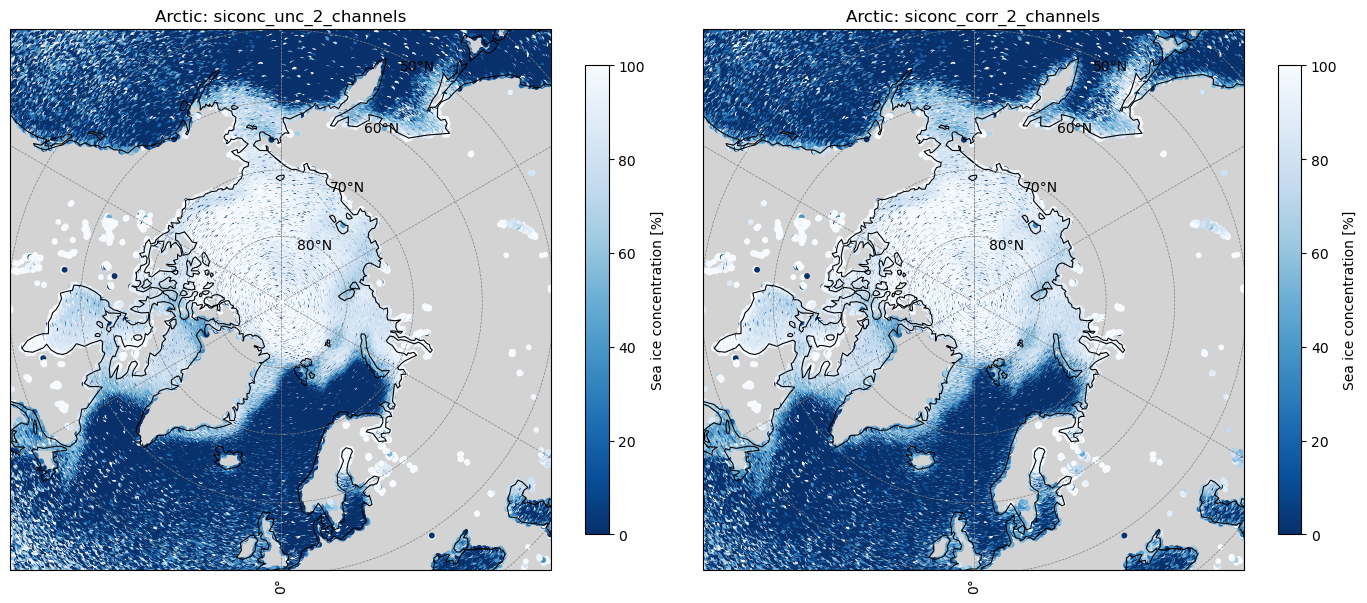

In [108]:
# VISUALIZATION
# Load data
file_path = "data_swath_final.txt" 
df = pd.read_csv(file_path, delim_whitespace=True)

# Variable selection
var1_name = "siconc_unc_2_channels"
var2_name = "siconc_corr_2_channels"
lat_name = "LAT"  
lon_name = "LON"  

# Convert in numpy array
lats = df[lat_name].values
lons = df[lon_name].values
var1 = df[var1_name].values*100
var2 = df[var2_name].values*100

# Plot
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 7), subplot_kw={'projection': ccrs.NorthPolarStereo()})

for ax, var, title in zip(axs, [var1, var2], [var1_name, var2_name]):
    ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightgray")
    
    # Variable selection
    sc = ax.scatter(lons, lats, c=var, cmap="Blues_r", s=10, transform=ccrs.PlateCarree())

    cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.7, pad=0.05)
    cbar.set_label("Sea ice concentration [%]")

    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
    gl.top_labels = False  
    gl.right_labels = False  
    gl.xlabel_style = {'size': 10, 'color': 'black'}
    gl.ylabel_style = {'size': 10, 'color': 'black'}

    ax.set_title(f"Arctic: {title}")

plt.tight_layout()
plt.show()

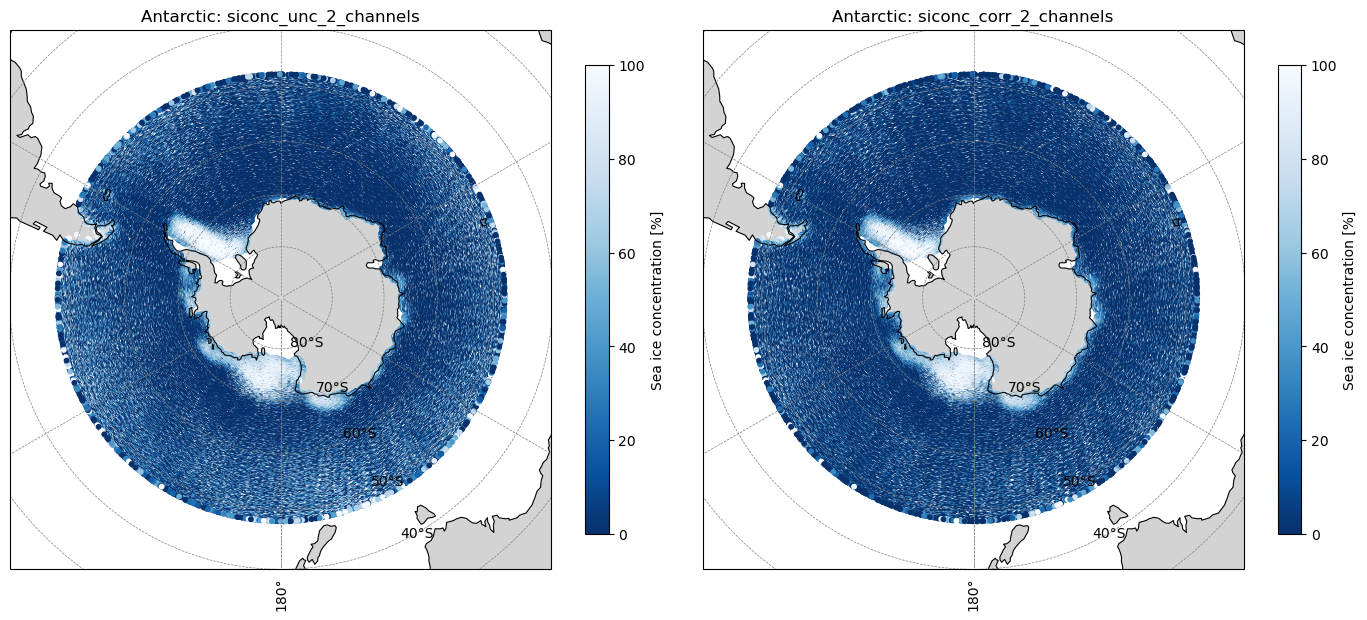

In [68]:
# Load data
file_path = "data_swath_final.txt" 
df = pd.read_csv(file_path, delim_whitespace=True)

# Variable selection
var1_name = "siconc_unc_2_channels"
var2_name = "siconc_corr_2_channels"
lat_name = "LAT"  
lon_name = "LON"  

# Convert in numpy array
lats = df[lat_name].values
lons = df[lon_name].values
var1 = df[var1_name].values*100
var2 = df[var2_name].values*100

# Plot
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 7), subplot_kw={'projection': ccrs.SouthPolarStereo()})

for ax, var, title in zip(axs, [var1, var2], [var1_name, var2_name]):
    ax.set_extent([-180, 180, -90, -40], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="white")
    
    # Variable selection
    sc = ax.scatter(lons, lats, c=var, cmap="Blues_r", s=10, transform=ccrs.PlateCarree())

    cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.7, pad=0.05)
    cbar.set_label("Sea ice concentration [%]")

    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
    gl.top_labels = False  
    gl.right_labels = False  
    gl.xlabel_style = {'size': 10, 'color': 'black'}
    gl.ylabel_style = {'size': 10, 'color': 'black'}

    ax.set_title(f"Antarctic: {title}")

plt.tight_layout()
plt.show()

In [69]:
import xarray as xr
import pandas as pd
import numpy as np
import os
import re
from datetime import datetime
import pyresample as pr
from pyresample import kd_tree, parse_area_file
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from pyresample.geometry import SwathDefinition
import sys, string, math, cmath
from numba import jit 
from tqdm import tqdm 
import time 
from pyresample.geometry import SwathDefinition
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.ticker import FixedLocator 
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import maximum_filter, minimum_filter
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import FixedLocator

# Load final swath data
file_path_swath = 'data_swath_final.txt'
data_swath = pd.read_csv(file_path_swath, delimiter='\t')

# Convert numeric columns
numeric_columns = ['TBCH1', 'TBCH2', 'TBCH3', 'LAT', 'LON', 'u10', 
                   'v10', 't2m', 'tcw', 'tcwv', 'sst', 'siconc',
                   'theta', 'clw', 'W', 'siconc_unc_ch1', 
                   'siconc_unc_ch2', 'T22_measured', 'T32_measured',
                   'T22_mean', 'T32_mean', 'TBCH1_corr', 'TBCH2_corr',
                   'siconc_ch1_corr', 'siconc_ch2_corr', 'siconc_unc_2_channels', 
                   'T22_measured_2_channels', 'T32_measured_2_channels', 
                   'T22_mean_2_channels', 'T32_mean_2_channels', 
                   'TBCH1_corr_2_channels', 'TBCH2_corr_2_channels','siconc_corr_2_channels']

data_swath[numeric_columns] = data_swath[numeric_columns].apply(pd.to_numeric, errors='coerce')
data_swath['datetime'] = pd.to_datetime(data_swath['datetime'])

# Add new columns for absolute changes
data_swath['change_TBCH1_1_channel'] = (data_swath['TBCH1_corr'] - data_swath['TBCH1'])
data_swath['change_TBCH2_1_channel'] = (data_swath['TBCH2_corr'] - data_swath['TBCH2'])
data_swath['change_TBCH1_2_channels'] = (data_swath['TBCH1_corr_2_channels'] - data_swath['TBCH1'])
data_swath['change_TBCH2_2_channels'] = (data_swath['TBCH2_corr_2_channels'] - data_swath['TBCH2'])
data_swath['change_siconc_22ghz_1_channel'] = (data_swath['siconc_ch1_corr'] - data_swath['siconc_unc_ch1'])
data_swath['change_siconc_32ghz_1_channel'] = (data_swath['siconc_ch2_corr'] - data_swath['siconc_unc_ch2'])
data_swath['change_siconc_2_channels'] = (data_swath['siconc_corr_2_channels'] - data_swath['siconc_unc_2_channels'])

# Add new numeric columns to the numeric_columns list
numeric_columns.extend([
    'change_TBCH1_1_channel', 'change_TBCH2_1_channel', 
    'change_TBCH1_2_channels', 'change_TBCH2_2_channels',
    'change_siconc_22ghz_1_channel', 'change_siconc_32ghz_1_channel',
    'change_siconc_2_channels'
])

# Southern Hemisphere Function
def resample_data_sh(data_swath):
    numeric_data = {col: data_swath[col].to_numpy() for col in numeric_columns}
    lat = data_swath['LAT'].to_numpy()
    lon = data_swath['LON'].to_numpy()
    lon, lat = pr.utils.check_and_wrap(lon, lat)
    combined_def = SwathDefinition(lons=lon, lats=lat)
    area_def_ease_sh = parse_area_file('areas_ease1.cfg', 'ease_sh')[0]

    resampled_data = {}
    for col, array in numeric_data.items():
        resampled_data[f'{col}_r'] = kd_tree.resample_nearest(
            combined_def, array, area_def_ease_sh, radius_of_influence=50000, fill_value=np.nan)

    land_mask_sh = Dataset('lmask_sh_ease_2501.nc', 'r').variables['lmask'][:]
    for col in resampled_data:
        resampled_data[col][np.isin(land_mask_sh, [2, 3])] = np.nan

    resampled_df = pd.DataFrame({key: value.flatten() for key, value in resampled_data.items()})
    return resampled_df

# Northern Hemisphere Function
def resample_data_nh(data_swath):
    numeric_data = {col: data_swath[col].to_numpy() for col in numeric_columns}
    lat = data_swath['LAT'].to_numpy()
    lon = data_swath['LON'].to_numpy()
    lon, lat = pr.utils.check_and_wrap(lon, lat)
    combined_def = SwathDefinition(lons=lon, lats=lat)
    area_def_ease_nh = parse_area_file('areas_ease1.cfg', 'ease_nh')[0]

    resampled_data = {}
    for col, array in numeric_data.items():
        resampled_data[f'{col}_r'] = kd_tree.resample_nearest(
            combined_def, array, area_def_ease_nh, radius_of_influence=50000, fill_value=np.nan)

    land_mask_nh = Dataset('lmask_nh_ease_2501.nc', 'r').variables['lmask'][:]
    for col in resampled_data:
        resampled_data[col][np.isin(land_mask_nh, [2, 3])] = np.nan

    resampled_df = pd.DataFrame({key: value.flatten() for key, value in resampled_data.items()})
    return resampled_df


# Generate resampled data
resampled_final_data_sh = resample_data_sh(data_swath)
resampled_final_data_nh = resample_data_nh(data_swath)

# Load EASE grid files
area_def_ease_sh = parse_area_file('areas_ease1.cfg', 'ease_sh')[0]
area_def_ease_nh = parse_area_file('areas_ease1.cfg', 'ease_nh')[0]

# Save the final DataFrames for each hemisphere to .TXT files
output_txt_path_sh = "resampled_final_data_sh.txt"
output_txt_path_nh = "resampled_final_data_nh.txt"

resampled_final_data_sh.to_csv(output_txt_path_sh, sep='\t', index=False, na_rep='NaN')
print(f"Data saved to {output_txt_path_sh}")

resampled_final_data_nh.to_csv(output_txt_path_nh, sep='\t', index=False, na_rep='NaN')
print(f"Data saved to {output_txt_path_nh}")

Data saved to resampled_final_data_sh.txt
Data saved to resampled_final_data_nh.txt


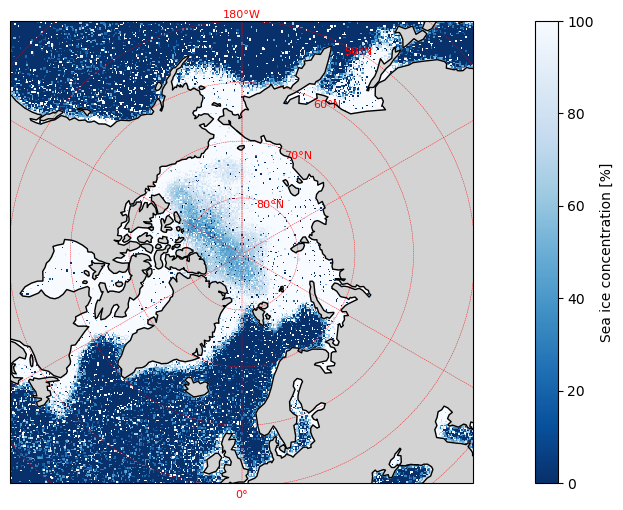

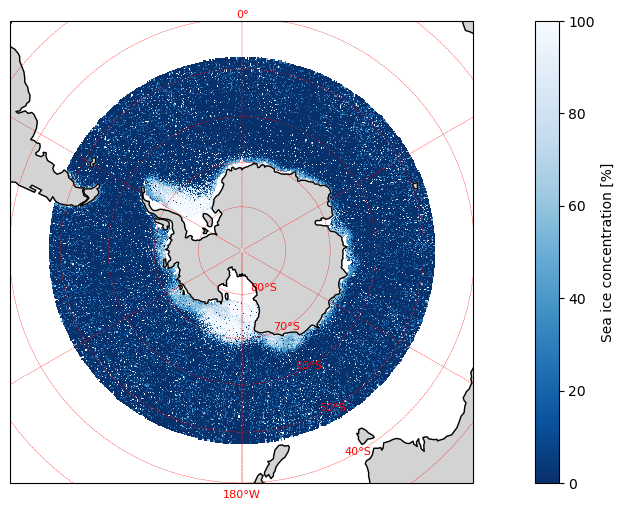

In [171]:
# Extract grid data
lons_sh, lats_sh = area_def_ease_sh.get_lonlats()
variable_to_plot_sh = resampled_final_data_sh['siconc_ch2_corr_r'].to_numpy().reshape(lons_sh.shape)

lons_nh, lats_nh = area_def_ease_nh.get_lonlats()
variable_to_plot_nh = resampled_final_data_nh['siconc_ch2_corr_r'].to_numpy().reshape(lons_sh.shape)

# Arctic SIC Plot
plt.figure(figsize=(8, 6), dpi=100)
ax = plt.axes(projection=ccrs.NorthPolarStereo())
ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())

plot_nh = ax.pcolormesh(lons_nh, lats_nh, variable_to_plot_nh*100, transform=ccrs.PlateCarree(), cmap='Blues_r', vmin=0, vmax=100, zorder=1)

# Add coastlines and land feature
ax.add_feature(cfeature.LAND, color='lightgrey', zorder=2)  # Color land in grey
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)

# Gridlines and labels
gridlines = ax.gridlines(draw_labels=True, color='red', linewidth=0.3, linestyle='--')
gridlines.top_labels = True
gridlines.right_labels = True
gridlines.xformatter = LONGITUDE_FORMATTER
gridlines.yformatter = LATITUDE_FORMATTER

gridlines.xlabel_style = {'size': 8, 'color': 'red', 'rotation': 0, 'ha': 'center', 'va': 'top'}
gridlines.ylabel_style = {'size': 8, 'color': 'red'}

# Colorbar and title
colorbar = plt.colorbar(plot_nh, orientation='vertical', pad=0.1)
colorbar.set_label('Sea ice concentration [%]', size=10)  # Add label
colorbar.ax.tick_params(labelsize=10)  # Increase tick size
plt.savefig('seaice_nh_2ch.png', dpi=300, bbox_inches='tight')
plt.show()

# Antarctic SIC Plot
plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -40], crs=ccrs.PlateCarree())

plot_sh = ax.pcolormesh(lons_sh, lats_sh, variable_to_plot_sh*100, transform=ccrs.PlateCarree(), cmap='Blues_r', vmin=0, vmax=100, zorder=1)

# Add coastlines and land feature, include ice shelves
ax.add_feature(cfeature.LAND, color='lightgrey',zorder=2)  # Color land in grey
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)

# Gridlines and latitude circles
gridlines = ax.gridlines(draw_labels=True, color='red', linewidth=0.3, linestyle='--')
gridlines.top_labels = True
gridlines.right_labels = True
gridlines.xformatter = LONGITUDE_FORMATTER
gridlines.yformatter = LATITUDE_FORMATTER

gridlines.xlabel_style = {'size': 8, 'color': 'red', 'rotation': 0, 'ha': 'center', 'va': 'top'}
gridlines.ylabel_style = {'size': 8, 'color': 'red'}
#gridlines.xlocator = FixedLocator(range(-180, 181, 45))
#gridlines.ylocator = FixedLocator(range(-90, -50, 10))  # Add latitude circles

# Colorbar and title
colorbar = plt.colorbar(plot_sh, orientation='vertical', pad=0.1)
colorbar.set_label('Sea ice concentration [%]', size=10)  # Add label
colorbar.ax.tick_params(labelsize=10)  # Increase tick size
plt.savefig('seaice_sh_2ch.png', dpi=300, bbox_inches='tight')
plt.show()

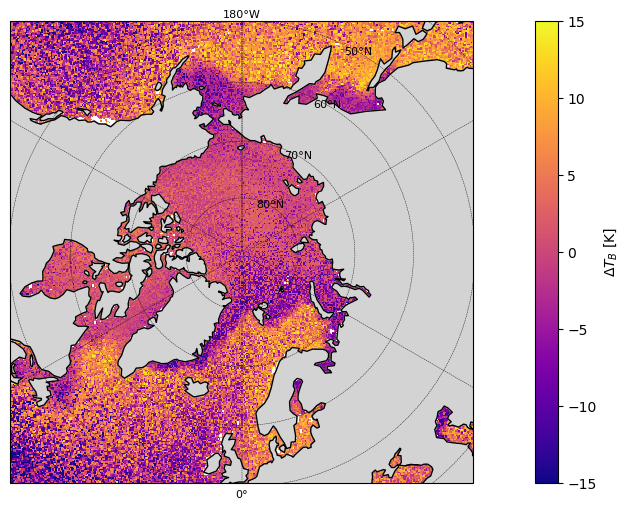

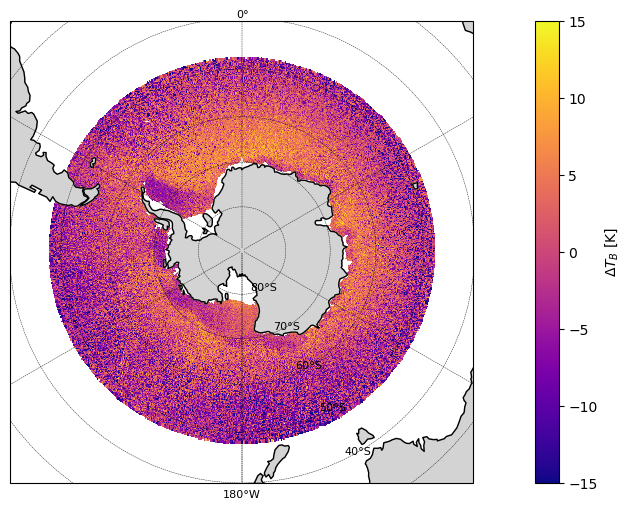

In [181]:
# Extract grid data
lons_sh, lats_sh = area_def_ease_sh.get_lonlats()
variable_to_plot_sh = resampled_final_data_sh['change_TBCH1_1_channel_r'].to_numpy().reshape(lons_sh.shape)

lons_nh, lats_nh = area_def_ease_nh.get_lonlats()
variable_to_plot_nh = resampled_final_data_nh['change_TBCH1_1_channel_r'].to_numpy().reshape(lons_sh.shape)

# Arctic SIC Plot
plt.figure(figsize=(8, 6), dpi=100)
ax = plt.axes(projection=ccrs.NorthPolarStereo())
ax.set_extent([-180, 180, 50, 90], crs=ccrs.PlateCarree())

plot_nh = ax.pcolormesh(lons_nh, lats_nh, variable_to_plot_nh, transform=ccrs.PlateCarree(), cmap='plasma', vmin=-15, vmax=15, zorder=1)

# Add coastlines and land feature
ax.add_feature(cfeature.LAND, color='lightgrey', zorder=2)  # Color land in grey
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)

# Gridlines and labels
gridlines = ax.gridlines(draw_labels=True, color='black', linewidth=0.3, linestyle='--')
gridlines.top_labels = True
gridlines.right_labels = True
gridlines.xformatter = LONGITUDE_FORMATTER
gridlines.yformatter = LATITUDE_FORMATTER

gridlines.xlabel_style = {'size': 8, 'color': 'black', 'rotation': 0, 'ha': 'center', 'va': 'top'}
gridlines.ylabel_style = {'size': 8, 'color': 'black'}

# Colorbar and title
colorbar = plt.colorbar(plot_nh, orientation='vertical', pad=0.1)
colorbar.set_label(r'$\Delta T_B$ [K]')
colorbar.ax.tick_params(labelsize=10)  # Increase tick size
plt.savefig('seaice_nh_2ch.png', dpi=300, bbox_inches='tight')
plt.show()

# Antarctic SIC Plot
plt.figure(figsize=(8,6), dpi=100)
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -40], crs=ccrs.PlateCarree())

plot_sh = ax.pcolormesh(lons_sh, lats_sh, variable_to_plot_sh, transform=ccrs.PlateCarree(), cmap='plasma', vmin=-15, vmax=15, zorder=1)

# Add coastlines and land feature, include ice shelves
ax.add_feature(cfeature.LAND, color='lightgrey',zorder=2)  # Color land in grey
ax.add_feature(cfeature.COASTLINE, linewidth=1, zorder=3)

# Gridlines and latitude circles
gridlines = ax.gridlines(draw_labels=True, color='black', linewidth=0.3, linestyle='--')
gridlines.top_labels = True
gridlines.right_labels = True
gridlines.xformatter = LONGITUDE_FORMATTER
gridlines.yformatter = LATITUDE_FORMATTER

gridlines.xlabel_style = {'size': 8, 'color': 'black', 'rotation': 0, 'ha': 'center', 'va': 'top'}
gridlines.ylabel_style = {'size': 8, 'color': 'black'}
#gridlines.xlocator = FixedLocator(range(-180, 181, 45))
#gridlines.ylocator = FixedLocator(range(-90, -50, 10))  # Add latitude circles

# Colorbar and title
colorbar = plt.colorbar(plot_sh, orientation='vertical', pad=0.1)
colorbar.set_label(r'$\Delta T_B$ [K]')
colorbar.ax.tick_params(labelsize=10)  # Increase tick size
plt.savefig('seaice_sh_2ch.png', dpi=300, bbox_inches='tight')
plt.show()